Hello, welcome to the example of how to use the glaciome model. 
I mostly run this via terminal, but I will python's 'os.system' and 'subprocess' to accomplish this from this notebook.
It is critical that you have the correct conda environment. See the attached .yml file for this. 

PACE is GA Tech's HPC, PAX is Tufts HPC (I call it this at least). 

In [ ]:
import os
import subprocess
import time
import fileinput
import sys
os.system('pwd')

The first thing we will do is move to 'elizaScripts' where there is a configuration file 'belugaModel.py'. You can edit specifics about this configuration from within this file, but for now it is configured to run a small, MPI run that will work on a mac computer (if you have MPI configured). This will also work on PACE/PAX, as the script is aware of where it is being run. IF PACE or PAX update their working directory naming schemes this could break, see notes there for how to update this. 

Once you are satified with the model run and name, execute this python script. This will make a new folder in the 'experiments' directory with the needed files. You MUST execute this file from inside the 'elizaScript' directory.

In [ ]:
os.chdir('elizaScripts')
os.system('pwd')

This script will ask you to confirm the set up and description. These will be recorded in a 'input/buildScript.py' and 'input/setupReport.txt' so you can remember what happened here when you come back to it later. Make good notes! You will simply call the method as 'python belugaModel.py' and then press enter, and then enter again after the prompt asks you confirm. If you don't like the scriptio, ctrl-c will kill the script and you can adjust it. 

Running this script will overwrite existing files/experiments, so be careful, you cannot undo this. 

The output is very long, and basically tells you everythig that is happening as it goes. Feel free to read the comments in that script to make more sense of it all. If you call this on a mac, matplotlib figures will pop up and must be dismissed to continue. These are also saved as PNGs in input/ for later viewing. 

In [ ]:
process = subprocess.Popen(['python', 'miniModel.py'], stdin=subprocess.PIPE, text=True)
time.sleep(2)

process.communicate(input='\n')

In [ ]:
#this will stop the above to release us to do other runs
process.terminate()

Now, you can navigate to the new run folder

In [ ]:
os.system('pwd')
os.chdir('../experiments/example_2')
os.system('pwd')

Now we have a wonderful run folder here. If you are on HPC, you may want to move this to scratch, or another large storage location. For this example we will not do that. All symlinks within this folder are full file paths, so can support moving anywhere you would like to go. Once in the final desination, you move into the run folder (where we are now). 

Next up is building the MITgcm code, as fortran is compiled. There are different versions for each system (PACE/PAX/Mac) so you must build on the system you intend to run it on. The building script again is smart and knows where it is being built. This again depends on the directory names as the root of PACE/PAX.

This is a bash script. You must point the script to the location of the MITgcm folder (relative or full path names both work), as well as include the option -mpi flag if this is a mpi run. You must call this script from the run folder. If you go to MITgcm.com and look at their documentation, this script is automating lots of the fun stuff required to make this go. My script is really just a little wrapper for their method genmake2. 

For what ever reason I can't make this work from this notebook, so navigate to this folder in a terminal, activate the proper conada env, and execute:
```bash ../makeBuild.sh ../../..``` (No '-mpi' flag this time, this is important)

This will have a ton of outputs, you can ignore warnings, but errors mean something is wrong with you compiler (likely) or the MITgcm code if you changed it (more likely). It may also ask you a funny pop up system warning/question about accepting outside connections or messing with your firewall. You can ignore or decline this as we wont MPI to any core over the network.

The preamble has the script clarify what machine it thinks it is running on, and clarified what building script it is using and where it is building. The FC_CHECK should be 5/5, but sometime 3/5 of is fine, 0/5 of means it will fail and you have a bad version of fortran/MPI enabled.  
```
Idenitfied machine as Mac
File Makefile does not exist, no cleaning needed
===== Building with darwin_amd64_gfortran at /Users/psummers8/Documents/MITgcm/MITgcm/experiments/example_2/build =====

GENMAKE :

A program for GENerating MAKEfiles for the MITgcm project.
   For a quick list of options, use "genmake2 -h"
or for more detail see the documentation, section "Building the model"
   (under "Getting Started") at:  https://mitgcm.readthedocs.io/

===  Processing options files and arguments  ===
  getting local config information:  none found
  getting OPTFILE information:
    using OPTFILE="../../../tools/build_options/darwin_amd64_gfortran"
    get Compiler-version: '15'
../../../tools/build_options/darwin_amd64_gfortran: line 119: nf-config: command not found
  getting AD_OPTFILE information:
    using AD_OPTFILE="../../../tools/adjoint_options/adjoint_default"
  check Fortran Compiler...  pass  (set FC_CHECK=5/5)
  check makedepend (local: 0, system: 1, 1)

===  Checking system libraries  ===
  Do we have the system() command using gfortran...  yes
  Do we have the fdate() command using gfortran...  yes
  Do we have the etime() command using gfortran... c,r: yes (SbR)
  Can we call simple C routines (here, "cloc()") using gfortran...  yes
  Can we unlimit the stack size using gfortran...  yes
  Can we register a signal handler using gfortran...  no
  Can we use stat() through C calls...  yes
  Can we create NetCDF-enabled binaries...  no
    skip check for LAPACK Libs
  Can we call FLUSH intrinsic subroutine...  yes
...
```

The end of the output should read something like:

```
Warning: 'psnorm' may be used uninitialized [-Wmaybe-uninitialized]
Warning: 'psnorm' may be used uninitialized [-Wmaybe-uninitialized]
ini_p_ground.for:3307:15:

 3307 |       Real*8  psNorm, rMidKp1
      |               ^~~~~~
note: 'psnorm' was declared here
port_rand.for:157:72:

  157 |       port_rand_norm = t*x1
      |                                                                        ^
Warning: 'x1' may be used uninitialized [-Wmaybe-uninitialized]
port_rand.for:140:14:

  140 |       real*8 x1, x2, xs, t
      |              ^~
note: 'x1' was declared here
Creating mitgcmuv ...
ld: warning: duplicate -rpath '/Users/psummers8/anaconda3/envs/MITgcm/lib' ignored
ld: warning: object file (ptwrapper.o) was built for newer macOS version (26.0) than being linked (16.0)
ld: warning: object file (setdir.o) was built for newer macOS version (26.0) than being linked (16.0)
ld: warning: ld: warning: object file (sigreg.o) was built for newer macOS version (26.0) than being linked (16.0)
ld: warning: object file (timer_stats.o) was built for newer macOS version (26.0) than being linked (16.0)
object file (setrlstk.o) was built for newer macOS version (26.0) than being linked (16.0)
ld: warning: object file (tim.o) was built for newer macOS version (26.0) than being linked (16.0)
ld: warning: object file (gsl_ieee_env.o) was built for newer macOS version (26.0) than being linked (16.0)
(⌐■_■) Done building
```

I am making this on June 16 after my computer was upgraded to a new OSX (26.0) but my gfortran was installed when I had OSX 16.0, so that is why I get some of those warnings. If your other packages are up to date, you should get fewer warnings.
Importantly, ```Creating mitgcmuv``` and the glasses man ```(⌐■_■)``` mean it worked. It also makes a fun noise on Mac, so don't let that surprise you. 

Wondeful, now you're almost ready. The `RunModelMpi.py` script uses ```melangeModel.py``` to control factors of the run. 'frestStart' assumes a fresh start, but setting this to false lets the job pick up any existing run and continue running for `iteratationsToRun' more days. For now we will change from the default to 5 days.


 (DO THIS YOURSELF NOW IN A TEXT EDITOR)

Now we are ready to go! To run the model we just call ```RunModelMpi.py```. This again detects what machine it is run on and request the approriate number of cores for MPI. This usually has no or very little output while MITgcm is running. To monitor the MITgcm run you should look at ```results/STDOUT.0001``` to monitor core 1, but any core can be monitored, I usualy pick a random one just to mix it up (```less results/STDOUT.0001``` works well), there is one for each core running. If there is only 1 core (like this run) then MPI will not be used, and the output is written to ```results/MITgcm_output.txt```. 

End notifications can have warnings, generally that is OK so long as no NaNs pop up. Underflow errors I think are that the tracers are initialized as 0 everywhere, so at the start they are below numeric precision. The mélange script updates you on how things are going with the mélange. This is also saved to ```couplingResults/out.txt```. Mélange files are the ```.pickle``` files in ```/couplingResults```. MITgcm files are saved as diagnoistic files in ```/results```. Read more about these on MITgcm.com. Here we have plotting scripts that rely on the exact configuration of these files. 

As a side note, this output is easy to ignore when things are going well but is full of INCREDIBLY useful information for tracking down issues in the MITgcm configuration
```
(PID.TID 0000.0001) // ======================================================
(PID.TID 0000.0001) //                      MITgcm UV
(PID.TID 0000.0001) //                      =========
(PID.TID 0000.0001) // ======================================================
(PID.TID 0000.0001) // execution environment starting up...
(PID.TID 0000.0001) 
(PID.TID 0000.0001) // MITgcmUV version:  checkpoint69g
(PID.TID 0000.0001) // Build user:        psummers8
(PID.TID 0000.0001) // Build host:        cos-2a15648.local
(PID.TID 0000.0001) // Build date:        Tue Jun 16 16:22:38 EDT 2026
(PID.TID 0000.0001) 
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) // Execution Environment parameter file "eedata"
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) ># "eedata" file
(PID.TID 0000.0001) ># Lines beginning "#" are comments
(PID.TID 0000.0001) ># nTx - No. threads per process in X
(PID.TID 0000.0001) ># nTy - No. threads per process in Y
(PID.TID 0000.0001) > &EEPARMS
(PID.TID 0000.0001) > nTx=1,
(PID.TID 0000.0001) > nTy=1,
(PID.TID 0000.0001) > /
(PID.TID 0000.0001) ># Note: Some systems use & as the namelist terminator (as shown here).
(PID.TID 0000.0001) >#       Other systems use a / character.
(PID.TID 0000.0001) 
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) // Computational Grid Specification ( see files "SIZE.h" )
(PID.TID 0000.0001) //                                  ( and "eedata"       )
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001)      nPx =    1 ; /* No. processes in X */
(PID.TID 0000.0001)      nPy =    1 ; /* No. processes in Y */
(PID.TID 0000.0001)      nSx =    1 ; /* No. tiles in X per process */
(PID.TID 0000.0001)      nSy =    1 ; /* No. tiles in Y per process */
(PID.TID 0000.0001)      sNx =   50 ; /* Tile size in X */
(PID.TID 0000.0001)      sNy =   16 ; /* Tile size in Y */
(PID.TID 0000.0001)      OLx =    3 ; /* Tile overlap distance in X */
(PID.TID 0000.0001)      OLy =    3 ; /* Tile overlap distance in Y */
(PID.TID 0000.0001)      nTx =    1 ; /* No. threads in X per process */
(PID.TID 0000.0001)      nTy =    1 ; /* No. threads in Y per process */
(PID.TID 0000.0001)       Nr =   32 ; /* No. levels in the vertical   */
(PID.TID 0000.0001)       Nx =   50 ; /* Total domain size in X ( = nPx*nSx*sNx ) */
(PID.TID 0000.0001)       Ny =   16 ; /* Total domain size in Y ( = nPy*nSy*sNy ) */
(PID.TID 0000.0001)   nTiles =    1 ; /* Total no. tiles per process ( = nSx*nSy ) */
(PID.TID 0000.0001)   nProcs =    1 ; /* Total no. processes ( = nPx*nPy ) */
(PID.TID 0000.0001) nThreads =    1 ; /* Total no. threads per process ( = nTx*nTy ) */
(PID.TID 0000.0001) usingMPI =    F ; /* Flag used to control whether MPI is in use */
...
```


MPI and MITgcm tends to make many many files as there are files for each core, and this gets crazy (like millions of files) if you have many cores, and many days (years) of data. To account for this the script is cleaning up files as it goes. Noteably it delets pickups that are more than 2 iterations old (but not diagnostics). This will attempt to delete negative time pickup files for first few iterations (`rm: results/pick*.-000005760.*: No such file or directory`), this is OK. Other errors are worth investigating. 

The script also reduces these 'tile' files to 'global' files which massively reduces file counts:
```
condensing diagnostic tiles files to global files iter:23040
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
```
So that is what those updates are telling you. I believe setting a setting in the `input/data` could do this within MITgcm (https://mitgcm.readthedocs.io/en/latest/getting_started/getting_started.html#input-output-files) but this is potentially a big pain to make work in MPI, and is possibly much slower for MITgcm which is already the slowest part of this model, so hence why I have thus far done it this way. If you edit which diagnostic files are made, this part might fail if it tries to edit files that aren't there. You can easily edit the list of files it looks for from the ```RunModelMpi.py``` script. For non-MPI runs this check still happens, but is strictly not needed. 

My plotting files (which use mitgcmutils) can plot from either tile or global files no problem. xmitgcm can ONLY use global files, and so if you want o use xmitgcm to say make a NETcdf file, you must wait for the run to finish and globalize all the files. My scripts can how ever preview at any point, and can even be used to visualize a run as it still going. 

If you are running this on PAX or PACE, a ```submitBatch.sh``` file should be auto generated for you within the run directory, (double check the email is right). It will also have an auto generate run time that is very short for testing (like 1 iteration), you should make this much longer for long runs, ~ 24 hours per model year is a rough order of magnitude. Currently this request 30 cores, which on both PAX and PACE seems to be close to the most efficient number of cores. To call this you simply need to run:
```sbatch submitBatch.sh```

In [8]:
#The -u flag lets it write output directly and not need to wait, 'unbuffered' what this -u flag stands for.
os.system('python -u RunModelMpi.py') #On my mac (14-inch MBP Nov 2023, Apple M3 Pro 18GB Mem) this take about 8-10 minutes. 
#This should kick off 1 mitgcmuv task you can see on activity monitor or htop

#The warnings from MITgcm below could likely be investigated more, but they have not caused issues yet.
#** Warning ** CONFIG_SUMMARY: should remove retired EXACT_CONSERV from CPP_OPTIONS.h
#** WARNING ** CONFIG_CHECK: Implicit viscosity applies to provisional u,vVel
#** WARNING ** => not consistent with final vertical shear (after appling 3-D solver solution
#** WARNING ** CONFIG_CHECK: Implicit viscosity not implemented in CALC_GW
#** WARNING ** CONFIG_CHECK: Explicit viscosity might become unstable if too large


Operating system identified as Darwin
Identified cores as 1.0 x 1.0 = 1.0, isMPI = False
Running from fresh start...
Assuming fresh MITgcm directory. Steps to run: 5...


** Warning ** CONFIG_SUMMARY: should remove retired EXACT_CONSERV from CPP_OPTIONS.h
** WARNING ** CONFIG_CHECK: Implicit viscosity applies to provisional u,vVel
** WARNING ** => not consistent with final vertical shear (after appling 3-D solver solution
** WARNING ** CONFIG_CHECK: Implicit viscosity not implemented in CALC_GW
** WARNING ** CONFIG_CHECK: Explicit viscosity might become unstable if too large
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
=== GLACIOME Running, load MITgcm data from end of day 1.00, using melange index 00000 === 
	Melt Rates min/mean/max: -0.31, -0.21, -0.18 [m/day]:
	Previous Length: 20953.945, H0: 171.406
	New      Length: 21003.992, H0: 171.495, ∆L: 50.047, ∆H0: 0.089
	term loc/depth     0/600.0 m, calving/glacier speed: 6000/6000 m/yr
		Seconds to run GLACIOME step: 1.6064
	Saved as MITgcmRun_00001.pickle
	Prepping MITgcm for day 2.00
	adjust start iteration 0 to 5760
	adjust end time 86400 to 172800


rm: results/pick*.-000011520.*: No such file or directory
** Warning ** CONFIG_SUMMARY: should remove retired EXACT_CONSERV from CPP_OPTIONS.h
** WARNING ** CONFIG_CHECK: Implicit viscosity applies to provisional u,vVel
** WARNING ** => not consistent with final vertical shear (after appling 3-D solver solution
** WARNING ** CONFIG_CHECK: Implicit viscosity not implemented in CALC_GW
** WARNING ** CONFIG_CHECK: Explicit viscosity might become unstable if too large
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


	condensing diagnostic tiles files to global files iter:11520
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
		Seconds to run coupled step: 90.6612
=== GLACIOME Running, load MITgcm data from end of day 2.00, using melange index 00001 === 
	Melt Rates min/mean/max: -3.61, -0.70, -0.11 [m/day]:
	Previous Length: 21003.992, H0: 171.495
	New      Length: 21047.051, H0: 168.534, ∆L: 43.059, ∆H0: -2.962
	term loc/depth     0/600.0 m, calving/glacier speed: 6000/6000 m/yr
		Seconds to run GLACIOME step: 2.0481
	Saved as MITgcmRun_00002.pickle
	Prepping MITgcm for day 3.00
	adjust start iteration 5760 to 11520
	adjust end time 172800 to 259200


...

** Warning ** CONFIG_SUMMARY: should remove retired EXACT_CONSERV from CPP_OPTIONS.h
** WARNING ** CONFIG_CHECK: Implicit viscosity applies to provisional u,vVel
** WARNING ** => not consistent with final vertical shear (after appling 3-D solver solution
** WARNING ** CONFIG_CHECK: Implicit viscosity not implemented in CALC_GW
** WARNING ** CONFIG_CHECK: Explicit viscosity might become unstable if too large
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


	condensing diagnostic tiles files to global files iter:28800
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
		Seconds to run coupled step: 92.7093
=== GLACIOME Running, load MITgcm data from end of day 5.00, using melange index 00004 === 
	Melt Rates min/mean/max: -4.75, -0.90, -0.07 [m/day]:
	Previous Length: 21183.181, H0: 166.916
	New      Length: 21245.874, H0: 167.847, ∆L: 62.692, ∆H0: 0.931
	term loc/depth     0/600.0 m, calving/glacier speed: 6000/6000 m/yr
		Seconds to run GLACIOME step: 2.1557
	Saved as MITgcmRun_00005.pickle
	Prepping MITgcm for day 6.00
	adjust start iteration 23040 to 28800
	adjust end time 432000 to 518400


** Warning ** CONFIG_SUMMARY: should remove retired EXACT_CONSERV from CPP_OPTIONS.h
** WARNING ** CONFIG_CHECK: Implicit viscosity applies to provisional u,vVel
** WARNING ** => not consistent with final vertical shear (after appling 3-D solver solution
** WARNING ** CONFIG_CHECK: Implicit viscosity not implemented in CALC_GW
** WARNING ** CONFIG_CHECK: Explicit viscosity might become unstable if too large
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG
STOP NORMAL END


	condensing diagnostic tiles files to global files iter:34560
		 == BRGFlx ==
		 == dynDiag ==
		 == ptraceDiag ==
		 == plumeDiag ==
		Seconds to run coupled step: 94.3960
	condensing grid tile files to global files
		== Depth ==
		== DXC ==
		== DXF ==
		== DXG ==
		== DXV ==
		== DYC ==
		== DYF ==
		== DYG ==
		== DYU ==
		== hFacC ==
		== hFacS ==
		== hFacW ==
		== maskInC ==
		== maskInS ==
		== maskInW ==
		== RAC ==
		== RAS ==
		== RAW ==
		== RAZ ==
		== XC ==
		== XG ==
		== YC ==
		== YG ==


0

For plotting you can use the scripts ```giflook...py``` which have help if you use the ```-h``` flag. These must be called from the run folder, but they live in the ```analysis``` folder, though there are symlinks in ```experiments``` for convenience. These make gifs which are saved in the ```figs``` folder.
Colors are controlled by the files ```input/plotHelper.py```.

In [11]:
os.system('python ../giflookSideAvg.py -h')

usage: giflookSideAvg.py [-h] [-q] [-k [KVALUES ...]] [-n [NUMFRAMES]]
                         [-t TIMERANGE TIMERANGE] [-s] [-xl [XLIMIT]]
                         [-dpi [DPI]]

Plot dynamics width averaged

options:
  -h, --help            show this help message and exit
  -q, --quick           quick option for last frame only, double to show
                        plot(s)
  -k, --kValues [KVALUES ...]
                        option specification of views to plot [default = all]
  -n, --numFrames [NUMFRAMES]
                        optional specification of numFrames [default = 60]
  -t, --timeRange TIMERANGE TIMERANGE
                        optional specification of start and endtime in DAYS
                        [default = Full Range]
  -s, --shadow          option of shadow for mélange [default (off)]
  -xl, --xlimit [XLIMIT]
                        optional max x [default = entire frame]
  -dpi, --dpi [DPI]     dpi spec [default = 125]


0

In [16]:
os.system('python ../giflookSideAvg.py -s') # -s for shadow which is how I show iceberg fraction in an overlay
os.system('python ../giflookMap.py -s -z -100') #specify depth of 100 meters
os.system('python ../gifMelange.py -f couplingResults/MITgcmRun_0') #specify where mélange files are kept

Found experiment plotting settings
Plot DPI: 175 ; clean PNGs: True ; usePcolor: False
dt is loaded as 15.0
startStep,sizeStep,maxStep: 5760,5760,34560; [Days 1.0,1.0,6.0]
Found icebergs for this run
averaging over all cross sections
	Temp
	Sal
	U
	W
	V
	TracePlume
	TraceBerg
	BRGmltRt
	BrgDrag_x
	BrgDrag_y
Found experiment plotting settings
Plot DPI: 175 ; clean PNGs: True ; usePcolor: False
** Manual zDepth detected **
dt is loaded as 15.0
startStep,sizeStep,maxStep: 5760 5760 34560
Found icebergs for this run
depth is z = -94.58164978027344 index 10
	Temp
	Sal
	U
	W
	V
	BRGmltRt
	TracePlume
	TraceBerg
	BrgDrag_x
	BrgDrag_y
	SPD
6
[0 1 2 3 4 5]
initial file is <_io.BufferedReader name='couplingResults/MITgcmRun_00000.pickle'>
	Subsampling at 1


0

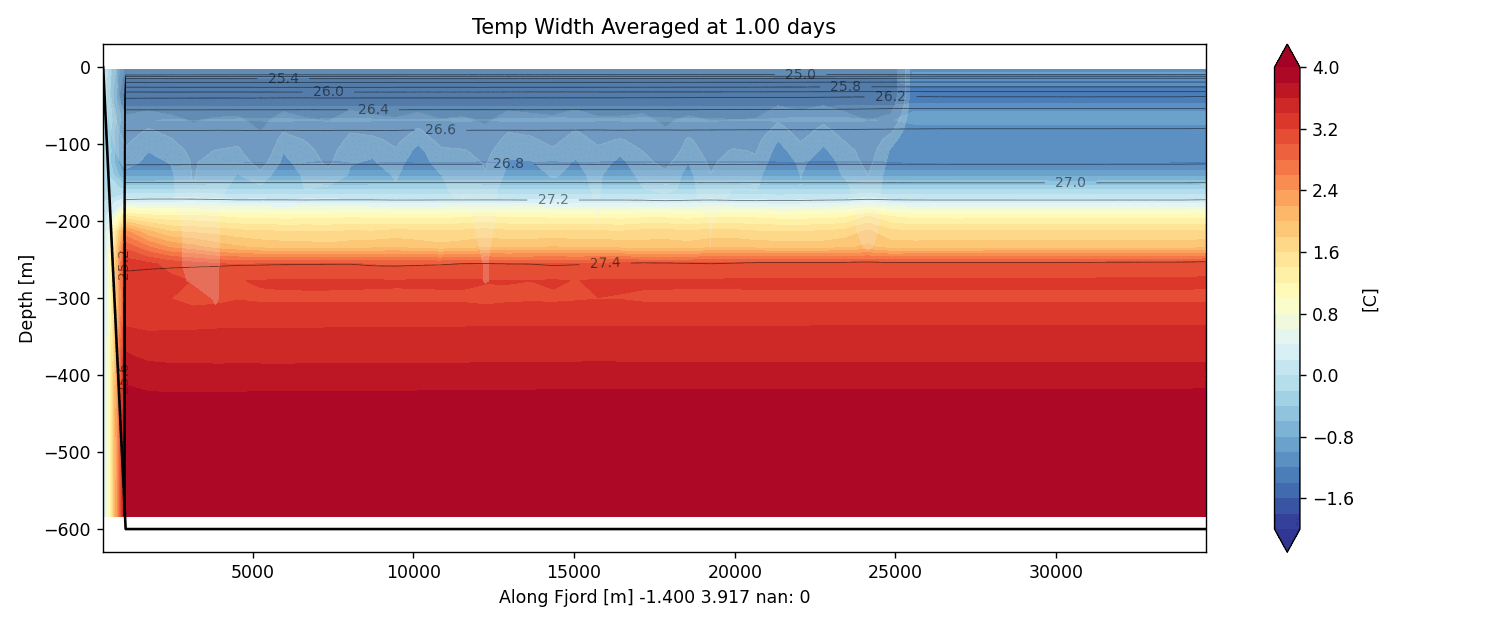

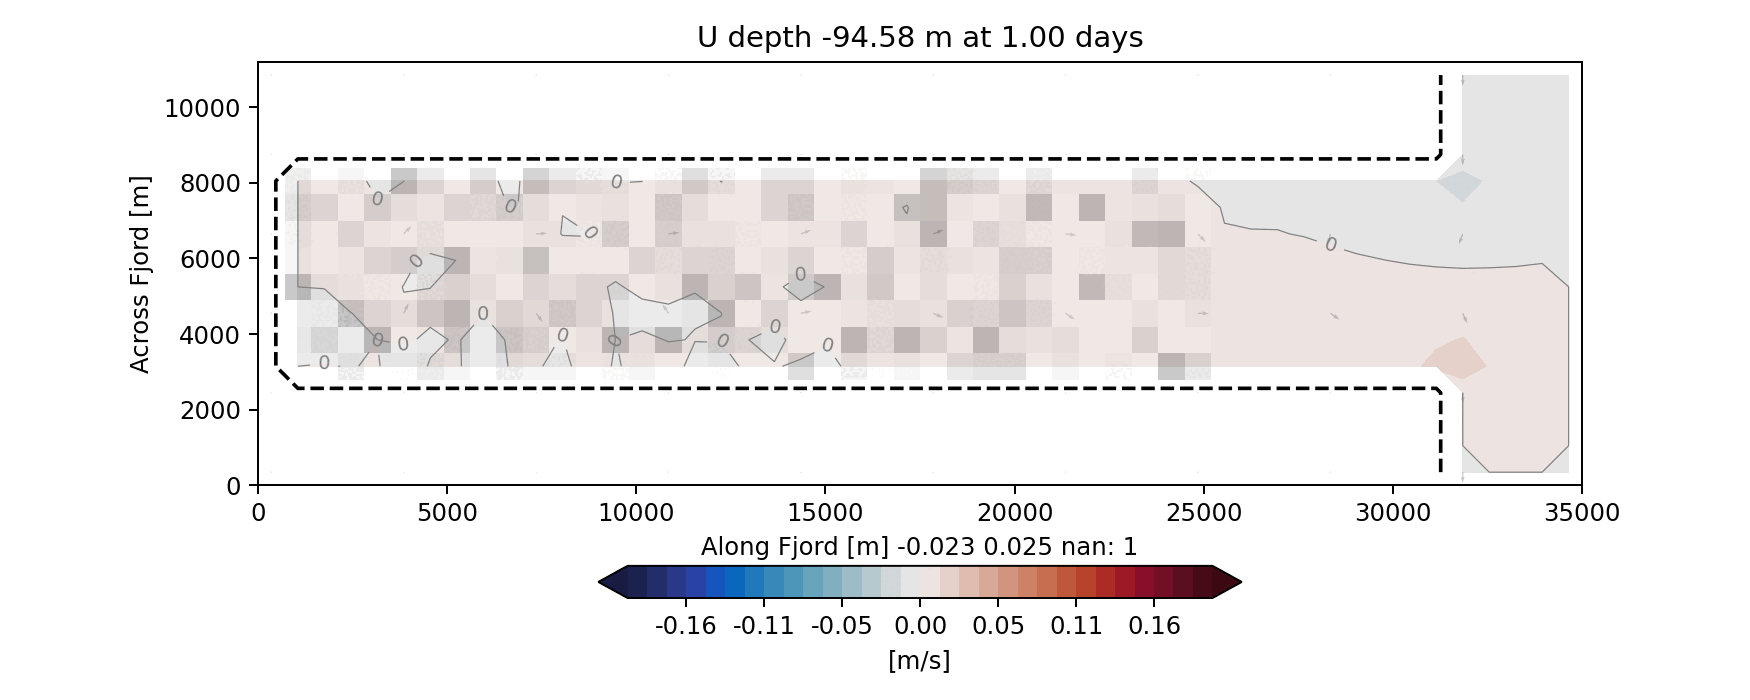

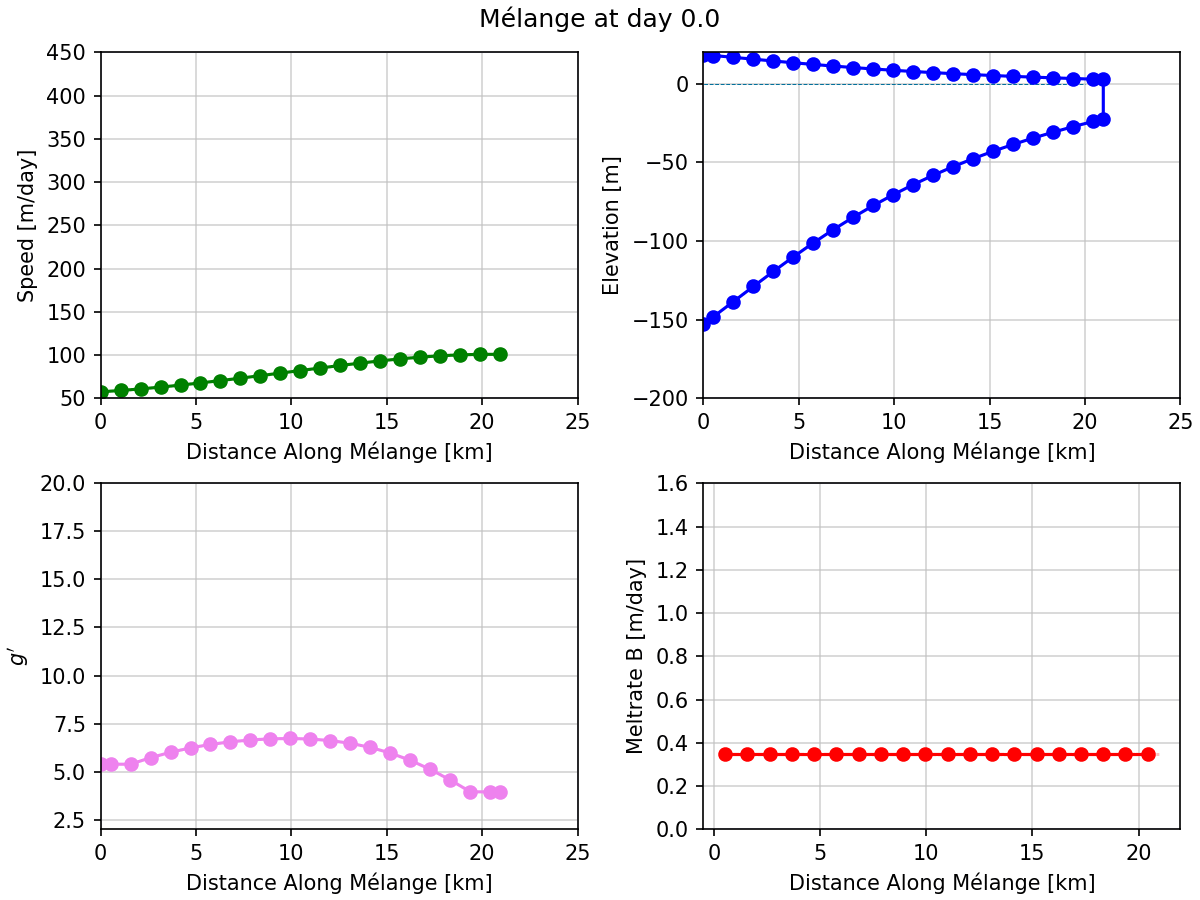

In [17]:
from IPython.display import Image, display

# The gif naming convention is a bit of a mess, sorry about that 
display(Image(filename="figs/sideAvg_Temp.gif"))
display(Image(filename="figs/autoMap100U.gif"))
display(Image(filename="figs/melange.gif"))
